## Imports

In [2]:
# ── Core Python ───────────────────────────────────────────
import os
import math
import time
import numpy as np
from tqdm import tqdm

# ── PyTorch Core ──────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

# ── Torchvision ───────────────────────────────────────────
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image

# ── Visualization ─────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Device setup ──────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Reproducibility ───────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("All imports successful ✅")

Using device: cuda
All imports successful ✅


## VAE Encoder

In [3]:
class VAEEncoder(nn.Module):
    """
    Encodes image into latent distribution (μ and σ).

    Input:  (B, 1, 32, 32)
    Output: μ (B, 4, 4, 4)
            σ (B, 4, 4, 4)
    """
    def __init__(self, in_channels=1, latent_channels=4):
        super().__init__()

        self.encoder = nn.Sequential(
            # Block 1: 1×32×32 → 32×16×16
            nn.Conv2d(in_channels, 32, 3, stride=2, padding=1),
            nn.SiLU(),

            # Block 2: 32×16×16 → 64×8×8
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.GroupNorm(8, 64),
            nn.SiLU(),

            # Block 3: 64×8×8 → 128×4×4
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.GroupNorm(8, 128),
            nn.SiLU(),
        )

        # Output μ and σ separately
        # latent_channels*2 because first half=μ, second half=σ
        self.out = nn.Conv2d(128, latent_channels * 2, 1)

    def forward(self, x):
        h = self.encoder(x)           # compress image
        h = self.out(h)               # (B, 8, 4, 4)

        # Split into μ and log_var along channel dim
        mu, log_var = h.chunk(2, dim=1)
        #  (B,4,4,4)  (B,4,4,4)

        return mu, log_var

## VAE Decoder

In [4]:
# ── VAE Decoder ───────────────────────────────────────────

class VAEDecoder(nn.Module):
    """
    Decompresses latent z back to image.
    Exact mirror of Encoder — upsamples instead of downsamples.

    Input:  z   (B, 4, 4, 4)
    Output: img (B, 1, 32, 32)
    """
    def __init__(self, latent_channels=4, out_channels=1, base_ch=32):
        super().__init__()

        # ── Input projection ─────────────────────────────
        # First expand latent channels to 128
        self.input_proj = nn.Conv2d(latent_channels, 128, 1)

        # ── Upsampling blocks ─────────────────────────────
        self.decoder = nn.Sequential(

            # Block 1: (128×4×4) → (64×8×8)
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.GroupNorm(8, 64),
            nn.SiLU(),

            # Block 2: (64×8×8) → (32×16×16)
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.GroupNorm(8, 32),
            nn.SiLU(),

            # Block 3: (32×16×16) → (1×32×32)
            nn.ConvTranspose2d(32, out_channels, 4, stride=2, padding=1),
        )

        # Final activation — tanh squashes output to [-1, 1]
        self.final_act = nn.Tanh()

    def forward(self, z):
        h = self.input_proj(z)      # (B, 128, 4, 4)
        h = self.decoder(h)         # (B, 1, 32, 32)
        return self.final_act(h)    # values in [-1, 1]




In [5]:
# ── Reparameterization trick ──────────────────────────────
def reparameterize(mu, log_var):
    """
    z = μ + σ × ε
    ε ~ N(0,1)  — random but not learned
    """
    sigma = torch.exp(0.5 * log_var)   # σ = e^(0.5 × log_var)
    eps   = torch.randn_like(sigma)    # ε ~ N(0,1)
    return mu + sigma * eps            # z


# ── Test Encoder + Decoder together ──────────────────────
encoder = VAEEncoder(in_channels=1, latent_channels=4).to(device)
decoder = VAEDecoder(latent_channels=4, out_channels=1).to(device)

# Test forward pass
x           = torch.randn(4, 1, 32, 32).to(device)
mu, log_var = encoder(x)
z           = reparameterize(mu, log_var)
x_recon     = decoder(z)

print(f"Input shape:        {x.shape}")        # (4, 1, 32, 32)
print(f"μ shape:            {mu.shape}")       # (4, 4, 4, 4)
print(f"log_var shape:      {log_var.shape}")  # (4, 4, 4, 4)
print(f"z shape:            {z.shape}")        # (4, 4, 4, 4)
print(f"Reconstructed shape:{x_recon.shape}")  # (4, 1, 32, 32)
assert x_recon.shape == x.shape, "Shape mismatch!"
print("Encoder + Decoder forward pass OK ✅")

Input shape:        torch.Size([4, 1, 32, 32])
μ shape:            torch.Size([4, 4, 4, 4])
log_var shape:      torch.Size([4, 4, 4, 4])
z shape:            torch.Size([4, 4, 4, 4])
Reconstructed shape:torch.Size([4, 1, 32, 32])
Encoder + Decoder forward pass OK ✅


## VAE Loss

In [6]:
# ── VAE Loss ──────────────────────────────────────────────

def vae_loss(x_recon, x_original, mu, log_var, kl_weight=0.001):
    """
    Total VAE Loss = Reconstruction Loss + KL Divergence Loss

    Args:
        x_recon:     reconstructed image from Decoder  (B, 1, 32, 32)
        x_original:  original image                    (B, 1, 32, 32)
        mu:          mean from Encoder                 (B, 4, 4, 4)
        log_var:     log variance from Encoder         (B, 4, 4, 4)
        kl_weight:   how much to weight KL loss
                     small value = focus on reconstruction
                     large value = focus on organized latent space

    Returns:
        total_loss, recon_loss, kl_loss
    """

    # ── Part 1: Reconstruction Loss ───────────────────────
    # How well does decoded image match original?
    # MSE = mean squared error between every pixel
    recon_loss = F.mse_loss(x_recon, x_original, reduction='mean')

    # ── Part 2: KL Divergence Loss ────────────────────────
    # Pushes μ → 0 and σ → 1
    # Forces latent space to be organized like N(0,1)
    #
    # Formula: -0.5 × sum(1 + log_var - μ² - e^log_var)
    kl_loss = -0.5 * torch.mean(
        1 + log_var - mu.pow(2) - log_var.exp()
    )

    # ── Total Loss ────────────────────────────────────────
    total_loss = recon_loss + kl_weight * kl_loss

    return total_loss, recon_loss, kl_loss


# ── Test the loss ─────────────────────────────────────────
x           = torch.randn(4, 1, 32, 32).to(device)
mu, log_var = encoder(x)
z           = reparameterize(mu, log_var)
x_recon     = decoder(z)

total, recon, kl = vae_loss(x_recon, x, mu, log_var)

print(f"Reconstruction Loss : {recon.item():.4f}")
print(f"KL Divergence Loss  : {kl.item():.4f}")
print(f"Total Loss          : {total.item():.4f}")
print("VAE Loss OK ✅")

Reconstruction Loss : 1.3605
KL Divergence Loss  : 0.0733
Total Loss          : 1.3606
VAE Loss OK ✅


##  VAE Training Loop

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 475kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Dataset: 60,000 images
Encoder params: 94,088
Decoder params: 165,281


Epoch 1/30:   0%|          | 0/469 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 1/30: 100%|██████████| 469/469 [00:18<00:00, 25.76it/s]


Epoch   1 | Total: 0.0382 | Recon: 0.0358 | KL: 2.3785


Epoch 2/30: 100%|██████████| 469/469 [00:16<00:00, 29.07it/s]


...

Epoch  28 | Total: 0.0082 | Recon: 0.0058 | KL: 2.4512


Epoch 29/30: 100%|██████████| 469/469 [00:16<00:00, 28.45it/s]


Epoch  29 | Total: 0.0082 | Recon: 0.0058 | KL: 2.4516


Epoch 30/30: 100%|██████████| 469/469 [00:16<00:00, 28.83it/s]


Epoch  30 | Total: 0.0082 | Recon: 0.0057 | KL: 2.4503
  Checkpoint saved ✅


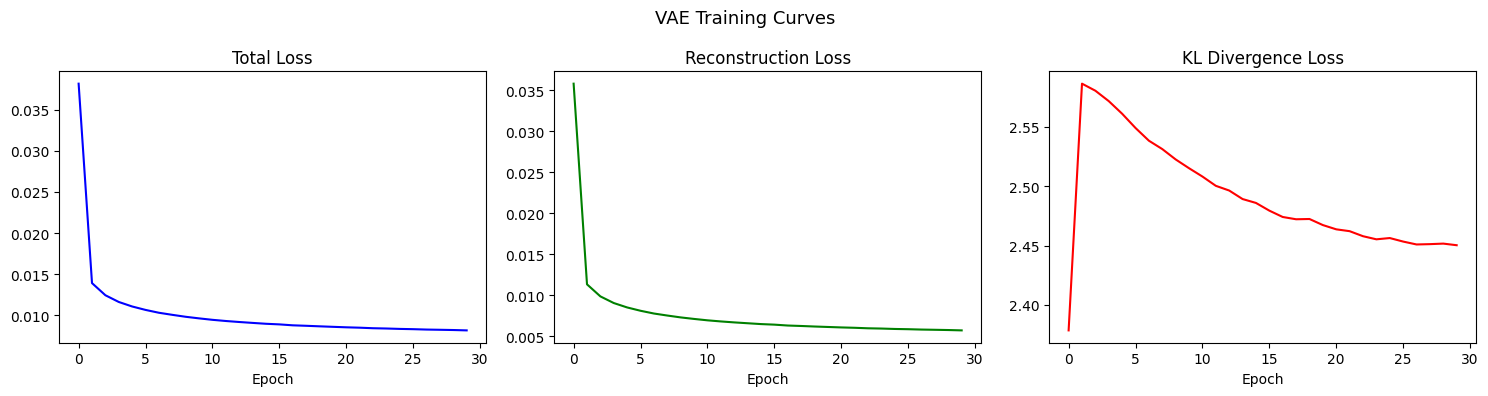

Saved: vae_training_curves.png


In [7]:
# ── Dataset ───────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # scale to [-1, 1]
])

dataset = datasets.MNIST(root='./data', train=True,
                         download=True, transform=transform)
loader  = DataLoader(dataset, batch_size=128,
                     shuffle=True, num_workers=4)
print(f"Dataset: {len(dataset):,} images")


# ── Initialize models + optimizer ─────────────────────────
encoder   = VAEEncoder(in_channels=1, latent_channels=4).to(device)
decoder   = VAEDecoder(latent_channels=4, out_channels=1).to(device)

# Train both encoder and decoder together
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=1e-3
)

print(f"Encoder params: {sum(p.numel() for p in encoder.parameters()):,}")
print(f"Decoder params: {sum(p.numel() for p in decoder.parameters()):,}")


# ── Training loop ─────────────────────────────────────────
EPOCHS    = 30
KL_WEIGHT = 0.001

# Track losses for plotting
history = {
    'total' : [],
    'recon' : [],
    'kl'    : []
}

for epoch in range(EPOCHS):
    encoder.train()
    decoder.train()

    total_loss_sum = 0
    recon_loss_sum = 0
    kl_loss_sum    = 0

    for x, _ in tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x = x.to(device)

        # ── Forward pass ──────────────────────────────────
        # Step 1: Encode image → μ and log_var
        mu, log_var = encoder(x)

        # Step 2: Sample z using reparameterization
        z = reparameterize(mu, log_var)

        # Step 3: Decode z → reconstructed image
        x_recon = decoder(z)

        # Step 4: Compute loss
        total, recon, kl = vae_loss(x_recon, x, mu, log_var, KL_WEIGHT)

        # ── Backward pass ─────────────────────────────────
        optimizer.zero_grad()
        total.backward()
        torch.nn.utils.clip_grad_norm_(
            list(encoder.parameters()) +
            list(decoder.parameters()), 1.0
        )
        optimizer.step()

        total_loss_sum += total.item()
        recon_loss_sum += recon.item()
        kl_loss_sum    += kl.item()

    # ── Epoch summary ─────────────────────────────────────
    n = len(loader)
    avg_total = total_loss_sum / n
    avg_recon = recon_loss_sum / n
    avg_kl    = kl_loss_sum    / n

    history['total'].append(avg_total)
    history['recon'].append(avg_recon)
    history['kl'].append(avg_kl)

    print(f"Epoch {epoch+1:3d} | "
          f"Total: {avg_total:.4f} | "
          f"Recon: {avg_recon:.4f} | "
          f"KL: {avg_kl:.4f}")

    # ── Save checkpoint every 10 epochs ───────────────────
    if (epoch + 1) % 10 == 0:
        torch.save({
            'encoder': encoder.state_dict(),
            'decoder': decoder.state_dict(),
            'optimizer': optimizer.state_dict(),
            'epoch': epoch + 1,
        }, f"vae_checkpoint_epoch{epoch+1}.pt")
        print(f"  Checkpoint saved ✅")


# ── Plot training curves ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['total'], color='blue')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')

axes[1].plot(history['recon'], color='green')
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch')

axes[2].plot(history['kl'], color='red')
axes[2].set_title('KL Divergence Loss')
axes[2].set_xlabel('Epoch')

plt.suptitle('VAE Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('vae_training_curves.png', dpi=150)
plt.show()
print("Saved: vae_training_curves.png")

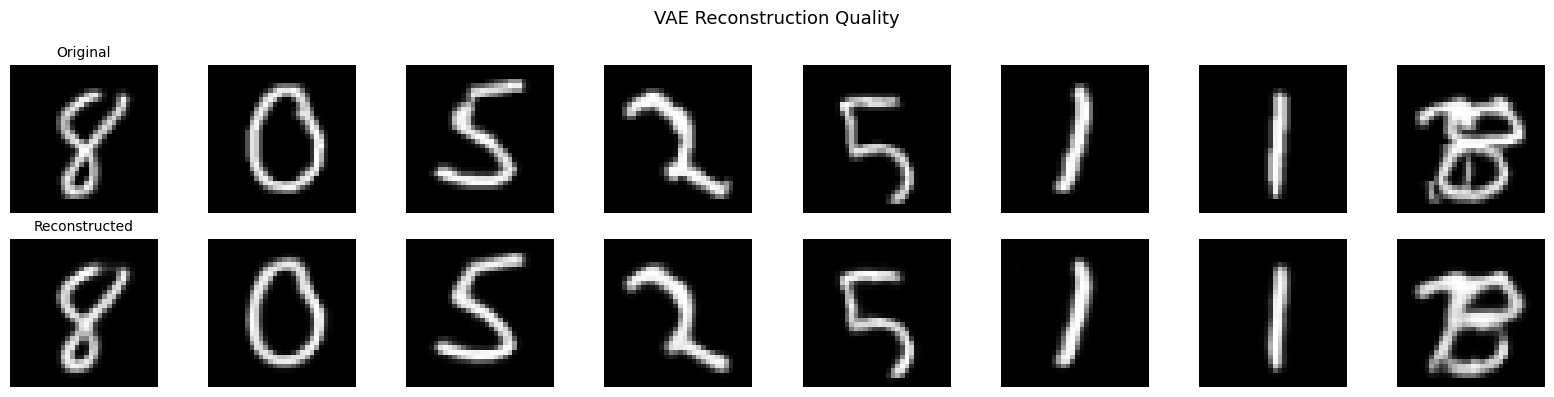

Saved: vae_reconstructions.png


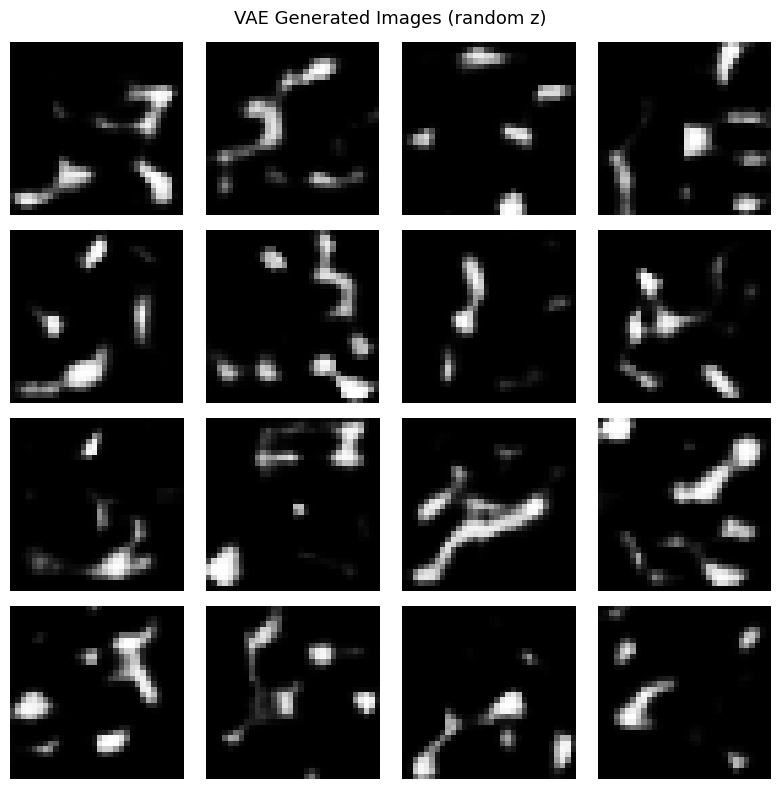

Saved: vae_generated.png


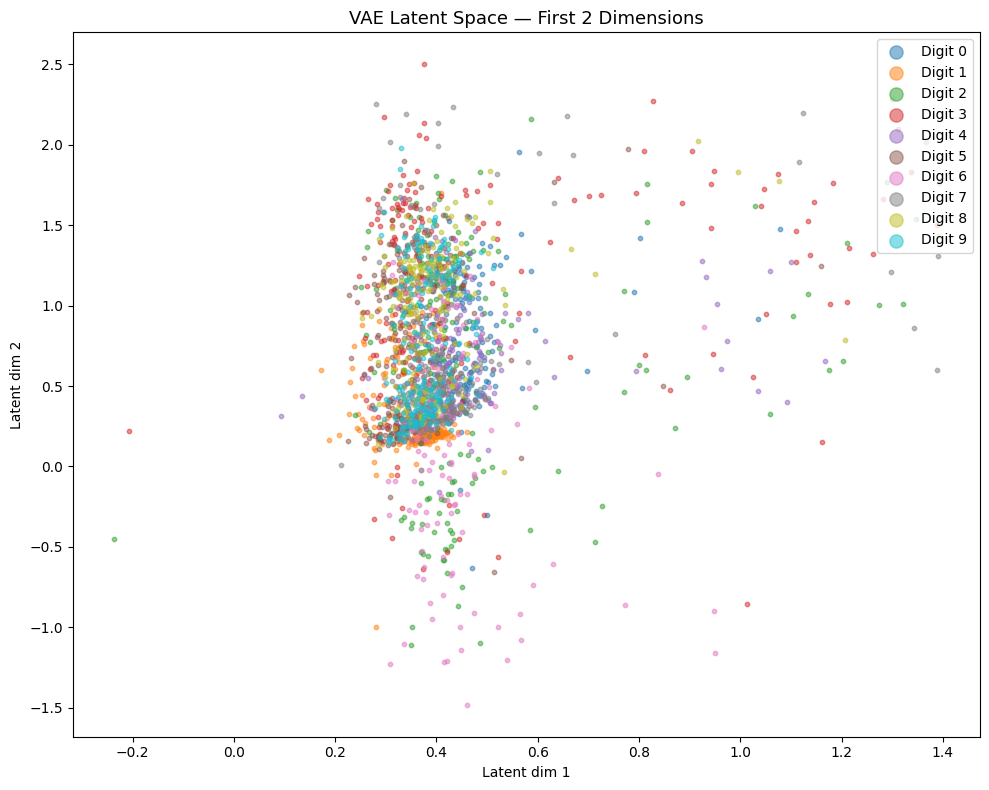

Saved: vae_latent_space.png


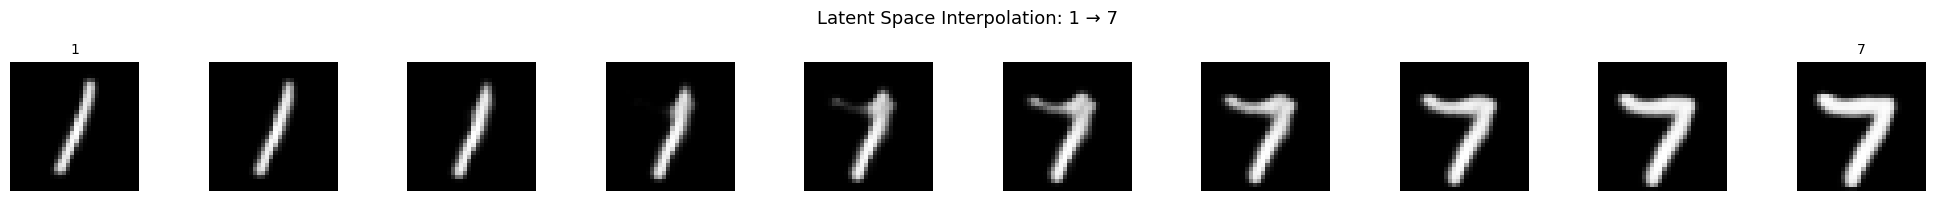

Saved: vae_interpolation.png


In [8]:
# ── Step 5: Visualize Results ─────────────────────────────

encoder.eval()
decoder.eval()


# ── Part A: Reconstruction Quality ────────────────────────
# Compare original images vs reconstructed images

@torch.no_grad()
def show_reconstructions(encoder, decoder, loader, n=8):
    """
    Show original images vs reconstructed images side by side.
    """
    # Get one batch
    x, _ = next(iter(loader))
    x     = x[:n].to(device)              # take first n images

    # Encode → sample z → decode
    mu, log_var = encoder(x)
    z           = reparameterize(mu, log_var)
    x_recon     = decoder(z)

    # Plot
    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))

    for i in range(n):
        # Original
        axes[0, i].imshow(
            x[i, 0].cpu().numpy(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontsize=10)

        # Reconstructed
        axes[1, i].imshow(
            x_recon[i, 0].cpu().numpy(), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Reconstructed', fontsize=10)

    plt.suptitle('VAE Reconstruction Quality', fontsize=13)
    plt.tight_layout()
    plt.savefig('vae_reconstructions.png', dpi=150)
    plt.show()
    print("Saved: vae_reconstructions.png")

show_reconstructions(encoder, decoder, loader)


# ── Part B: Generate NEW images from random z ─────────────
# Sample random z from N(0,1) and decode

@torch.no_grad()
def generate_from_noise(decoder, n=16):
    """
    Generate brand new images by sampling
    random z from standard normal distribution.
    """
    # Sample random latent vectors
    z = torch.randn(n, 4, 4, 4).to(device)   # z ~ N(0,1)

    # Decode to images
    samples = decoder(z)

    # Plot 4×4 grid
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i, 0].cpu().numpy(), cmap='gray')
        ax.axis('off')

    plt.suptitle('VAE Generated Images (random z)', fontsize=13)
    plt.tight_layout()
    plt.savefig('vae_generated.png', dpi=150)
    plt.show()
    print("Saved: vae_generated.png")

generate_from_noise(decoder)


# ── Part C: Latent Space Visualization ────────────────────
# Encode all test images → plot their μ in 2D
# Shows how well VAE organizes different digits

@torch.no_grad()
def visualize_latent_space(encoder, n_samples=2000):
    """
    Encode images and plot their latent vectors in 2D.
    Each digit gets a different color.
    Shows if VAE learned organized latent space.
    """
    # Use test dataset for cleaner visualization
    test_dataset = datasets.MNIST(
        root='./data', train=False,
        download=True, transform=transform
    )
    test_loader = DataLoader(
        test_dataset, batch_size=256, shuffle=True
    )

    all_mu     = []
    all_labels = []

    for x, labels in test_loader:
        x            = x.to(device)
        mu, log_var  = encoder(x)

        # Flatten spatial dims: (B,4,4,4) → (B,64)
        mu_flat = mu.view(mu.shape[0], -1)

        all_mu.append(mu_flat.cpu())
        all_labels.append(labels)

        if len(all_mu) * 256 >= n_samples:
            break

    # Stack all
    all_mu     = torch.cat(all_mu,     dim=0)[:n_samples]
    all_labels = torch.cat(all_labels, dim=0)[:n_samples]

    # Reduce to 2D using PCA
    # (latent is 64-dim, we show first 2 dims)
    mu_2d = all_mu[:, :2].numpy()   # take first 2 dimensions

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))

    colors = plt.cm.tab10(np.linspace(0, 1, 10))

    for digit in range(10):
        mask = all_labels == digit
        ax.scatter(
            mu_2d[mask, 0],
            mu_2d[mask, 1],
            c=[colors[digit]],
            label=f'Digit {digit}',
            alpha=0.5,
            s=10
        )

    ax.legend(markerscale=3, loc='upper right')
    ax.set_title('VAE Latent Space — First 2 Dimensions', fontsize=13)
    ax.set_xlabel('Latent dim 1')
    ax.set_ylabel('Latent dim 2')
    plt.tight_layout()
    plt.savefig('vae_latent_space.png', dpi=150)
    plt.show()
    print("Saved: vae_latent_space.png")

visualize_latent_space(encoder)


# ── Part D: Interpolation between two digits ──────────────
# Walk from one digit's latent to another's
# Shows smooth transition = good latent space

@torch.no_grad()
def interpolate_digits(encoder, decoder, loader, steps=10):
    """
    Interpolate between two different digits in latent space.
    If interpolation is smooth → latent space is well organized.
    """
    # Get two different images
    x, labels = next(iter(loader))

    # Find digit 1 and digit 7
    idx_1 = (labels == 1).nonzero()[0].item()
    idx_7 = (labels == 7).nonzero()[0].item()

    x1 = x[idx_1:idx_1+1].to(device)   # digit 1
    x7 = x[idx_7:idx_7+1].to(device)   # digit 7

    # Encode both
    mu1, _ = encoder(x1)
    mu7, _ = encoder(x7)

    # Interpolate between z1 and z7
    # alpha goes from 0 → 1 in `steps` steps
    alphas  = torch.linspace(0, 1, steps).to(device)
    results = []

    for alpha in alphas:
        z_interp = (1 - alpha) * mu1 + alpha * mu7   # blend
        img      = decoder(z_interp)
        results.append(img)

    # Plot interpolation
    fig, axes = plt.subplots(1, steps, figsize=(2*steps, 2))

    for i, img in enumerate(results):
        axes[i].imshow(img[0, 0].cpu().numpy(), cmap='gray')
        axes[i].axis('off')
        if i == 0:
            axes[i].set_title('1', fontsize=10)
        if i == steps-1:
            axes[i].set_title('7', fontsize=10)

    plt.suptitle('Latent Space Interpolation: 1 → 7', fontsize=13)
    plt.tight_layout()
    plt.savefig('vae_interpolation.png', dpi=150)
    plt.show()
    print("Saved: vae_interpolation.png")

interpolate_digits(encoder, decoder, loader)

##  LDM U-Net

In [10]:
# ── Cross Attention Block ─────────────────────────────────
class CrossAttention(nn.Module):
    """
    Cross attention between noisy latent (query)
    and conditioning signal (key, value).

    Args:
        dim:      channel dimension of latent features
        context_dim: dimension of conditioning vector
        n_heads:  number of attention heads
    """
    def __init__(self, dim, context_dim, n_heads=4):
        super().__init__()

        self.n_heads  = n_heads
        self.head_dim = dim // n_heads
        self.scale    = self.head_dim ** -0.5   # 1/√d

        # Q comes from latent (what U-Net is processing)
        self.to_q = nn.Linear(dim, dim, bias=False)

        # K and V come from conditioning (class/text)
        self.to_k = nn.Linear(context_dim, dim, bias=False)
        self.to_v = nn.Linear(context_dim, dim, bias=False)

        # Output projection
        self.to_out = nn.Linear(dim, dim)

    def forward(self, x, context):
        """
        Args:
            x:       latent features  (B, H*W, dim)
            context: conditioning     (B, seq_len, context_dim)
        """
        B, N, C = x.shape

        # Compute Q, K, V
        Q = self.to_q(x)        # (B, N, dim)
        K = self.to_k(context)  # (B, seq_len, dim)
        V = self.to_v(context)  # (B, seq_len, dim)

        # Split into multiple heads
        # (B, N, dim) → (B, n_heads, N, head_dim)
        Q = Q.reshape(B, N, self.n_heads, self.head_dim).transpose(1, 2)
        K = K.reshape(B, -1, self.n_heads, self.head_dim).transpose(1, 2)
        V = V.reshape(B, -1, self.n_heads, self.head_dim).transpose(1, 2)

        # Attention scores
        # (B, n_heads, N, head_dim) × (B, n_heads, head_dim, seq_len)
        attn = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)       # normalize

        # Weighted sum of values
        out = torch.matmul(attn, V)       # (B, n_heads, N, head_dim)

        # Merge heads back
        out = out.transpose(1, 2).reshape(B, N, C)

        return self.to_out(out)

In [11]:
# ── Attention ResBlock ────────────────────────────────────
class AttnResBlock(nn.Module):
    """
    ResBlock + CrossAttention combined.
    Used in bottleneck of LDM U-Net.

    Flow:
    x → ResBlock → CrossAttention → output
    """
    def __init__(self, in_ch, out_ch, t_dim,
                 context_dim=128, n_heads=4):
        super().__init__()

        # Normal ResBlock (same as before)
        self.norm1  = nn.GroupNorm(8, in_ch)
        self.conv1  = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.t_proj = nn.Linear(t_dim, out_ch)
        self.norm2  = nn.GroupNorm(8, out_ch)
        self.conv2  = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip   = nn.Conv2d(in_ch, out_ch, 1) \
                      if in_ch != out_ch else nn.Identity()

        # Cross-Attention layers
        self.norm_attn = nn.LayerNorm(out_ch)
        self.attn      = CrossAttention(
                             dim=out_ch,
                             context_dim=context_dim,
                             n_heads=n_heads
                         )

    def forward(self, x, t_emb, context):
        """
        Args:
            x:       feature map    (B, in_ch, H, W)
            t_emb:   time embedding (B, t_dim)
            context: conditioning   (B, seq_len, context_dim)
        """
        # ── ResBlock part ─────────────────────────────────
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.t_proj(F.silu(t_emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        h = h + self.skip(x)                   # (B, out_ch, H, W)

        # ── Cross-Attention part ──────────────────────────
        B, C, H, W = h.shape

        # Reshape for attention: (B, C, H, W) → (B, H*W, C)
        h_flat = h.permute(0, 2, 3, 1).reshape(B, H*W, C)

        # Apply cross-attention with conditioning
        h_flat = h_flat + self.attn(
            self.norm_attn(h_flat), context
        )

        # Reshape back: (B, H*W, C) → (B, C, H, W)
        h = h_flat.reshape(B, H, W, C).permute(0, 3, 1, 2)

        return h

In [13]:
# ── Sinusoidal Time Embedding ─────────────────────────────
class SinusoidalPE(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half   = self.dim // 2
        freqs  = torch.exp(
            -torch.arange(half, device=device) * (np.log(10000) / (half - 1))
        )
        args = t[:, None].float() * freqs[None]
        return torch.cat([args.sin(), args.cos()], dim=-1)


# ── Residual Block ────────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim):
        super().__init__()
        self.norm1  = nn.GroupNorm(8, in_ch)
        self.conv1  = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.t_proj = nn.Linear(t_dim, out_ch)
        self.norm2  = nn.GroupNorm(8, out_ch)
        self.conv2  = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip   = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.t_proj(F.silu(t_emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

In [14]:
# ── LDM U-Net ─────────────────────────────────────────────
class LDMUNet(nn.Module):
    """
    U-Net for LDM — operates on latent space z (4×4×4)
    with cross-attention for conditioning.

    Changes from SimpleUNet:
    1. Input channels = latent_channels (4) not img_channels
    2. Bottleneck uses AttnResBlock (cross-attention)
    3. Takes context (conditioning) as input
    """
    def __init__(self, latent_channels=4, base_ch=64,
                 t_dim=128, context_dim=128, num_classes=10):
        super().__init__()

        # ── Time embedding ────────────────────────────────
        self.t_mlp = nn.Sequential(
            SinusoidalPE(t_dim),
            nn.Linear(t_dim, t_dim * 4),
            nn.SiLU(),
            nn.Linear(t_dim * 4, t_dim),
        )

        # ── Class conditioning ────────────────────────────
        # Converts class label → context vector
        # context_dim must match CrossAttention context_dim
        self.class_emb  = nn.Embedding(num_classes + 1, context_dim)
        self.null_token = num_classes   # index 10 = no class

        ch = base_ch

        # ── Encoder ───────────────────────────────────────
        # Input is latent z (4 channels) not raw image
        self.init_conv = nn.Conv2d(latent_channels, ch, 3, padding=1)
        self.pool      = nn.MaxPool2d(2)
        self.down1     = ResBlock(ch,   ch*2, t_dim)
        self.down2     = ResBlock(ch*2, ch*4, t_dim)

        # ── Bottleneck WITH cross-attention ───────────────
        self.bot1 = AttnResBlock(ch*4, ch*4, t_dim,
                                 context_dim=context_dim)
        self.bot2 = AttnResBlock(ch*4, ch*4, t_dim,
                                 context_dim=context_dim)

        # ── Decoder ───────────────────────────────────────
        self.up1 = ResBlock(ch*4 + ch*2, ch*2, t_dim)
        self.up2 = ResBlock(ch*2 + ch,   ch,   t_dim)
        self.up  = nn.Upsample(scale_factor=2, mode='nearest')

        # Output channels = latent_channels (predict noise in z space)
        self.out = nn.Sequential(
            nn.GroupNorm(8, ch),
            nn.SiLU(),
            nn.Conv2d(ch, latent_channels, 1),
        )

    def forward(self, z, t, class_label=None):
        """
        Args:
            z:           noisy latent    (B, 4, 4, 4)
            t:           timestep        (B,)
            class_label: digit 0-9      (B,) or None
        """
        B = z.shape[0]

        # Time embedding
        t_emb = self.t_mlp(t)                          # (B, t_dim)

        # Class conditioning → context
        if class_label is None:
            class_label = torch.full(
                (B,), self.null_token,
                device=z.device, dtype=torch.long
            )
        # context shape: (B, 1, context_dim)
        # seq_len=1 because one class token
        context = self.class_emb(class_label).unsqueeze(1)

        # ── Encoder ───────────────────────────────────────
        x1 = self.init_conv(z)                         # (B, ch,   4, 4)
        x2 = self.down1(self.pool(x1), t_emb)          # (B, ch*2, 2, 2)
        x3 = self.down2(self.pool(x2), t_emb)          # (B, ch*4, 1, 1)

        # ── Bottleneck (with cross-attention) ─────────────
        b  = self.bot1(x3, t_emb, context)             # (B, ch*4, 1, 1)
        b  = self.bot2(b,  t_emb, context)             # (B, ch*4, 1, 1)

        # ── Decoder ───────────────────────────────────────
        h  = self.up1(torch.cat([self.up(b),  x2], dim=1), t_emb)
        h  = self.up2(torch.cat([self.up(h),  x1], dim=1), t_emb)

        return self.out(h)                              # (B, 4, 4, 4)


# ── Test LDM U-Net ────────────────────────────────────────
ldm_unet = LDMUNet(
    latent_channels=4,
    base_ch=64,
    t_dim=128,
    context_dim=128,
    num_classes=10
).to(device)

print(f"LDM U-Net params: {sum(p.numel() for p in ldm_unet.parameters()):,}")

# Sanity check
z_test = torch.randn(4, 4, 4, 4).to(device)    # latent
t_test = torch.randint(0, 1000, (4,)).to(device)
l_test = torch.randint(0, 10,   (4,)).to(device)

out_cond   = ldm_unet(z_test, t_test, l_test)  # conditioned
out_uncond = ldm_unet(z_test, t_test, None)    # unconditioned

assert out_cond.shape   == z_test.shape
assert out_uncond.shape == z_test.shape
print(f"Input  shape: {z_test.shape}")         # (4, 4, 4, 4)
print(f"Output shape: {out_cond.shape}")       # (4, 4, 4, 4)
print("LDM U-Net forward pass OK ✅")

LDM U-Net params: 4,983,364
Input  shape: torch.Size([4, 4, 4, 4])
Output shape: torch.Size([4, 4, 4, 4])
LDM U-Net forward pass OK ✅


## LDM Training Loop

Dataset: 60,000 images
LDM U-Net params : 4,983,364
VAE frozen        ✅


Epoch 1/50: 100%|██████████| 469/469 [00:23<00:00, 19.66it/s]


Epoch   1 | Loss: 0.1830


Epoch 2/50: 100%|██████████| 469/469 [00:23<00:00, 19.97it/s]


Epoch   2 | Loss: 0.1208


...

Epoch  48 | Loss: 0.0976


Epoch 49/50: 100%|██████████| 469/469 [00:23<00:00, 20.07it/s]


Epoch  49 | Loss: 0.0967


Epoch 50/50: 100%|██████████| 469/469 [00:22<00:00, 20.95it/s]


Epoch  50 | Loss: 0.0979
  Checkpoint saved ✅


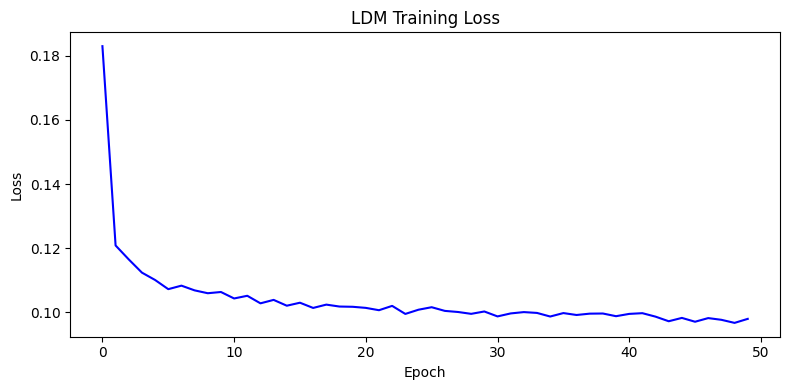

Saved: ldm_training_loss.png


In [15]:
# ── Noise Schedule (same as before) ──────────────────────
T      = 1000
betas  = torch.linspace(1e-4, 0.02, T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod           = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)


def extract(a, t, x_shape):
    B   = t.shape[0]
    out = a.gather(-1, t)
    return out.reshape(B, *((1,) * (len(x_shape) - 1)))


def q_sample(z0, t, noise=None):
    """
    Forward process on LATENT z — not pixel image!
    zt = √ᾱt * z0 + √(1-ᾱt) * ε
    """
    if noise is None:
        noise = torch.randn_like(z0)
    sqrt_ab_t   = extract(sqrt_alphas_cumprod,           t, z0.shape)
    sqrt_1mab_t = extract(sqrt_one_minus_alphas_cumprod, t, z0.shape)
    return sqrt_ab_t * z0 + sqrt_1mab_t * noise, noise


# ── Dataset ───────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(root='./data', train=True,
                         download=True, transform=transform)
loader  = DataLoader(dataset, batch_size=128,
                     shuffle=True, num_workers=4)
print(f"Dataset: {len(dataset):,} images")


# ── Initialize LDM U-Net ──────────────────────────────────
ldm_unet = LDMUNet(
    latent_channels=4,
    base_ch=64,
    t_dim=128,
    context_dim=128,
    num_classes=10
).to(device)

# ── Freeze VAE — we don't train it anymore ────────────────
# VAE is already trained, just use it to encode images
encoder.eval()
decoder.eval()
for param in encoder.parameters():
    param.requires_grad = False
for param in decoder.parameters():
    param.requires_grad = False

print(f"LDM U-Net params : {sum(p.numel() for p in ldm_unet.parameters()):,}")
print(f"VAE frozen        ✅")


# ── Optimizer ─────────────────────────────────────────────
optimizer = torch.optim.Adam(ldm_unet.parameters(), lr=2e-4)
EPOCHS    = 50
DROP_PROB = 0.1   # CFG label dropout


# ── LDM Training Loop ─────────────────────────────────────
history = {'loss': []}

for epoch in range(EPOCHS):
    ldm_unet.train()
    total_loss = 0

    for x0, labels in tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x0     = x0.to(device)
        labels = labels.to(device)
        B      = x0.shape[0]

        # ── Step 1: Encode image to latent ────────────────
        # VAE encoder compresses image to z
        # No gradient needed — VAE is frozen
        with torch.no_grad():
            mu, log_var = encoder(x0)
            z0          = reparameterize(mu, log_var)
            # Scale z to reasonable range for diffusion
            z0          = z0 * 0.5

        # ── Step 2: Sample random timestep ────────────────
        t = torch.randint(0, T, (B,), device=device).long()

        # ── Step 3: Add noise to latent z ─────────────────
        # Forward process on z not on image!
        noise  = torch.randn_like(z0)
        zt, _  = q_sample(z0, t, noise)

        # ── Step 4: CFG label dropout ─────────────────────
        drop_mask              = torch.rand(B, device=device) < DROP_PROB
        labels_dropped         = labels.clone()
        labels_dropped[drop_mask] = ldm_unet.null_token

        # ── Step 5: Predict noise in latent space ─────────
        pred_noise = ldm_unet(zt, t, labels_dropped)

        # ── Step 6: MSE loss (same as DDPM) ───────────────
        loss = F.mse_loss(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            ldm_unet.parameters(), 1.0
        )
        optimizer.step()

        total_loss += loss.item()

    avg = total_loss / len(loader)
    history['loss'].append(avg)
    print(f"Epoch {epoch+1:3d} | Loss: {avg:.4f}")

    # ── Save checkpoint every 10 epochs ───────────────────
    if (epoch + 1) % 10 == 0:
        torch.save({
            'ldm_unet' : ldm_unet.state_dict(),
            'optimizer': optimizer.state_dict(),
            'epoch'    : epoch + 1,
        }, f"ldm_checkpoint_epoch{epoch+1}.pt")
        print(f"  Checkpoint saved ✅")


# ── Plot training loss ────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(history['loss'], color='blue')
plt.title('LDM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.savefig('ldm_training_loss.png', dpi=150)
plt.show()
print("Saved: ldm_training_loss.png")

## LDM Sampling Functions

LDM Sampling class=9 scale=7.5: 100%|██████████| 50/50 [00:00<00:00, 82.79it/s]


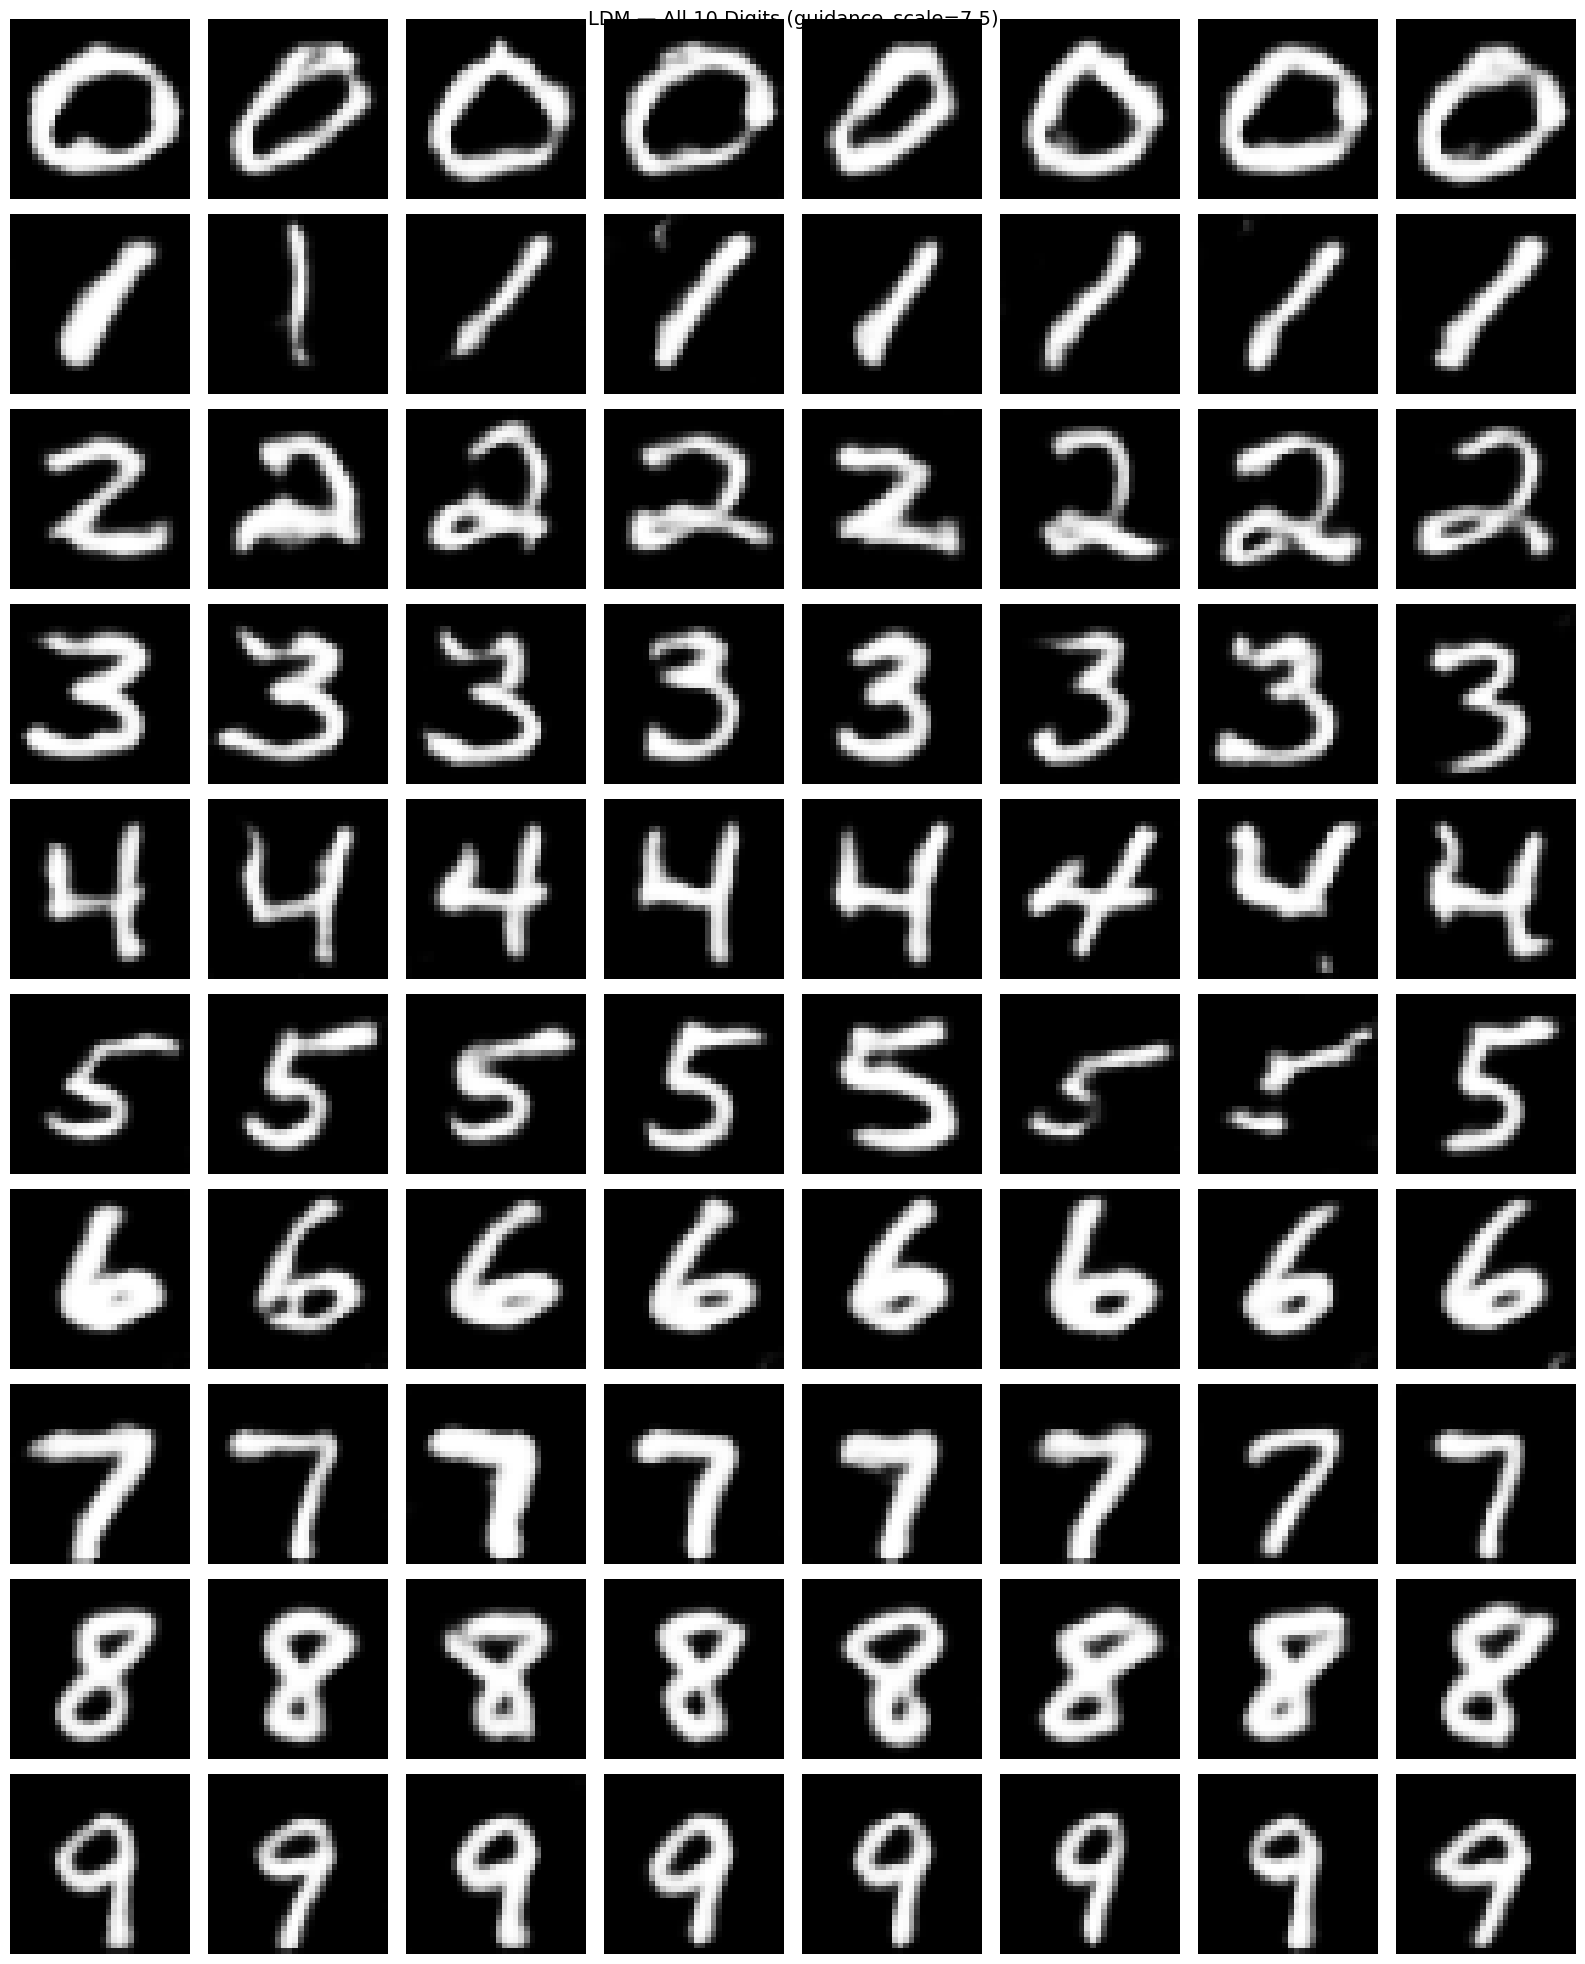

Saved: ldm_all_digits.png


LDM Sampling class=7 scale=15.0: 100%|██████████| 50/50 [00:00<00:00, 101.76it/s]


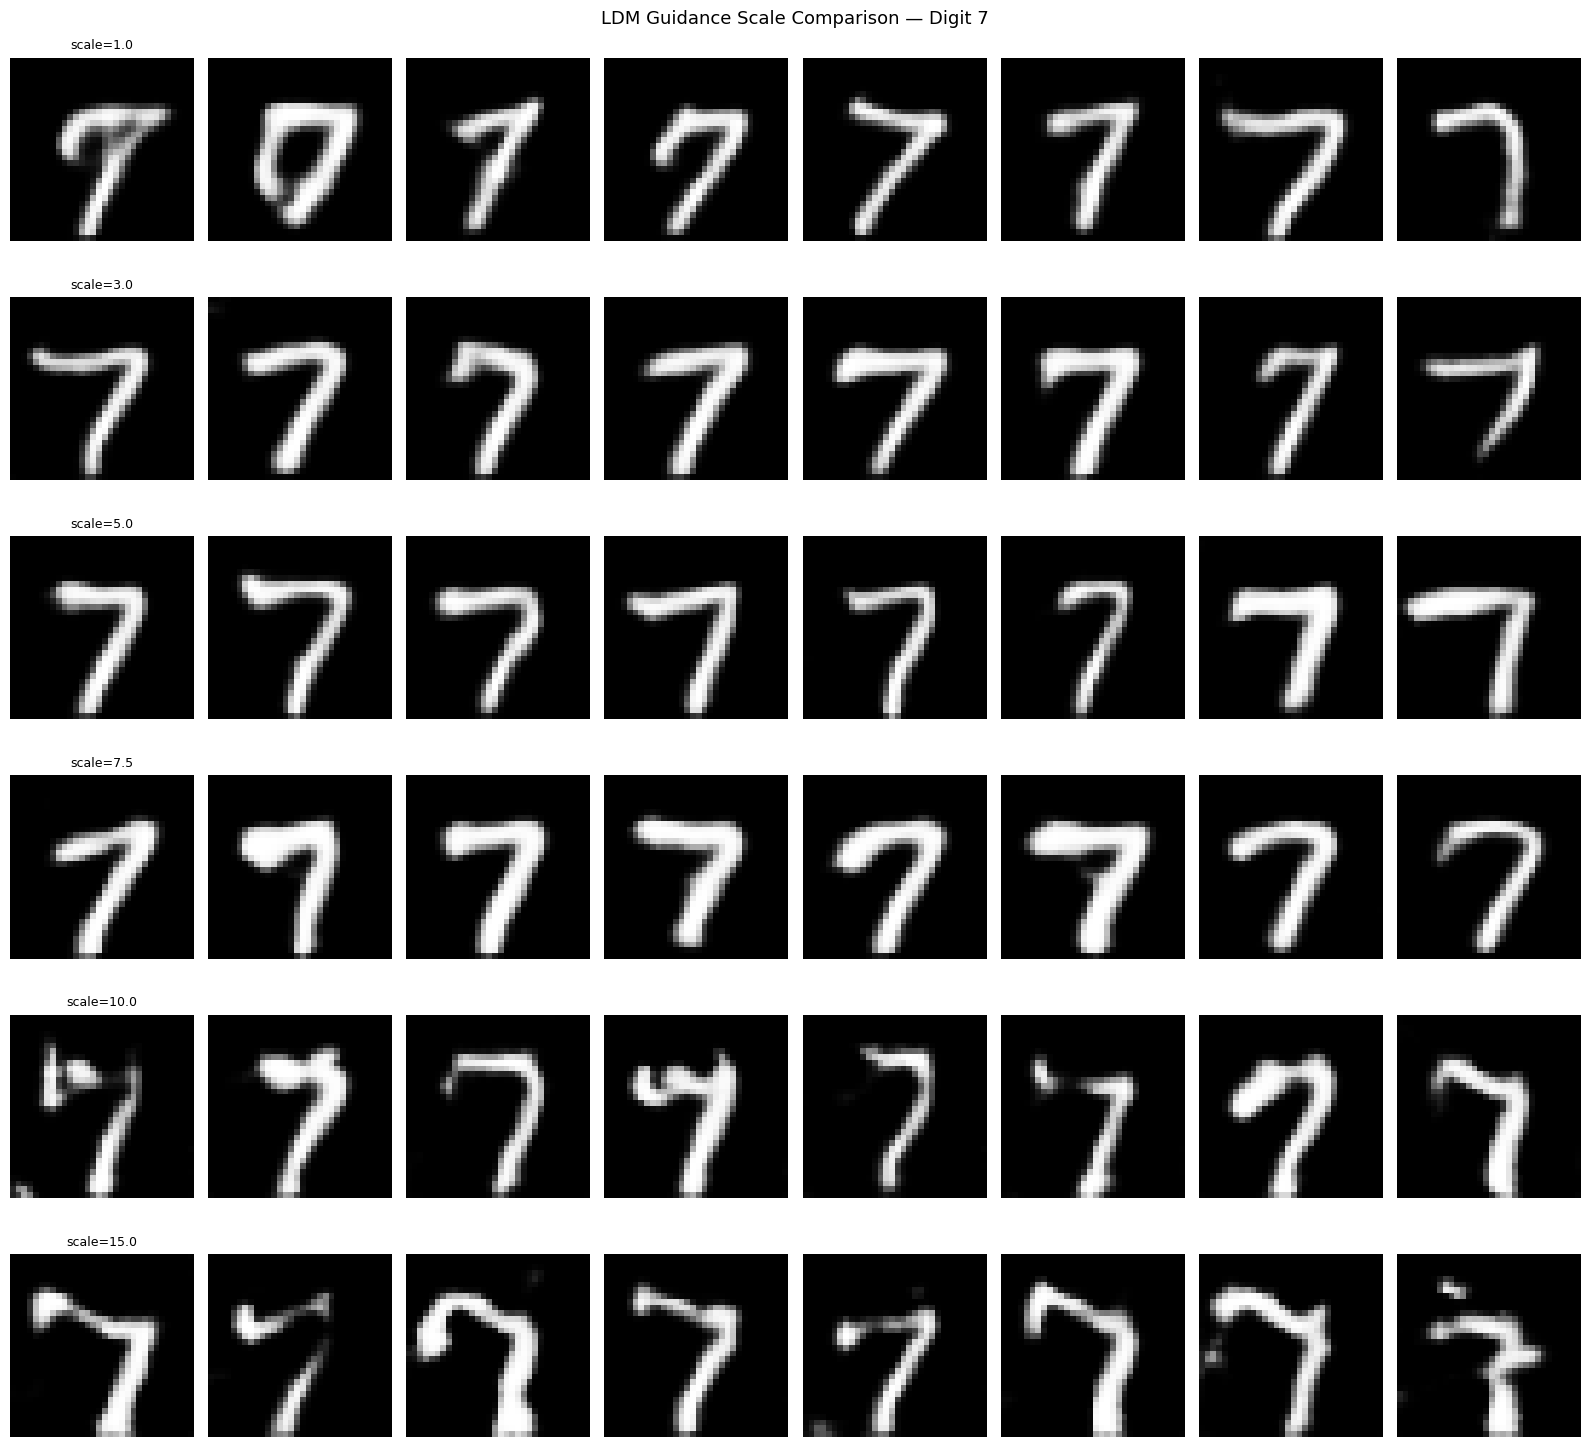

Saved: ldm_scale_comparison.png

Comparing sampling speed...


LDM Sampling class=0 scale=7.5: 100%|██████████| 50/50 [00:00<00:00, 94.51it/s]

LDM  (50  steps): 0.5s

LDM is fast because:
  → diffusion runs on 4×4×4 latent
     not on 1×32×32 pixels
  → 16x fewer values to process!


In [16]:
# ── LDM Sampling Functions ────────────────────────────────

@torch.no_grad()
def ldm_ddim_step(ldm_unet, zt, t, t_prev,
                  class_label, guidance_scale=7.5):
    """
    One CFG + DDIM step in LATENT space.

    Same as before but:
    - operates on z (4×4×4) not image (1×32×32)
    - uses LDM U-Net with cross-attention
    """
    # ── Run LDM U-Net twice (CFG) ─────────────────────────
    noise_cond   = ldm_unet(zt, t, class_label)   # conditioned
    noise_uncond = ldm_unet(zt, t, None)           # unconditioned

    # ── CFG formula ───────────────────────────────────────
    # ε_final = ε_uncond + scale × (ε_cond - ε_uncond)
    pred_noise = noise_uncond + guidance_scale * (
                     noise_cond - noise_uncond
                 )

    # ── DDIM step in latent space ─────────────────────────
    sqrt_ab_t   = extract(sqrt_alphas_cumprod,
                          t, zt.shape)
    sqrt_1mab_t = extract(sqrt_one_minus_alphas_cumprod,
                          t, zt.shape)

    # Estimate clean latent z0
    pred_z0 = (zt - sqrt_1mab_t * pred_noise) / sqrt_ab_t
    pred_z0 = pred_z0.clamp(-3, 3)             # clip latent range

    # Final step
    if t_prev is None:
        return pred_z0

    # Jump to t_prev
    sqrt_ab_prev   = extract(sqrt_alphas_cumprod,
                             t_prev, zt.shape)
    sqrt_1mab_prev = extract(sqrt_one_minus_alphas_cumprod,
                             t_prev, zt.shape)

    z_prev = sqrt_ab_prev * pred_z0 + sqrt_1mab_prev * pred_noise
    return z_prev


@torch.no_grad()
def sample_ldm(ldm_unet, decoder, class_label,
               n=16, ddim_steps=50, guidance_scale=7.5):
    """
    Full LDM sampling pipeline:
    random noise → DDIM → clean z → VAE Decoder → image

    Args:
        class_label:    digit to generate (0-9)
        n:              number of images
        ddim_steps:     DDIM steps (50 is good)
        guidance_scale: CFG strength (7.5 is good)
    """
    ldm_unet.eval()
    decoder.eval()

    # ── Step 1: Start from random noise in latent space ───
    # Shape = (n, latent_channels, 4, 4)
    zt = torch.randn(n, 4, 4, 4).to(device)

    # ── Step 2: Class label tensor ─────────────────────────
    labels = torch.full(
        (n,), class_label,
        device=device, dtype=torch.long
    )

    # ── Step 3: DDIM timestep subsequence ─────────────────
    timesteps = torch.linspace(
        0, T-1, ddim_steps
    ).long().flip(0).to(device)

    # ── Step 4: DDIM denoising loop ───────────────────────
    for i, t_now in enumerate(tqdm(
            timesteps,
            desc=f"LDM Sampling class={class_label} "
                 f"scale={guidance_scale}")):

        t_tensor = torch.full(
            (n,), t_now,
            device=device, dtype=torch.long
        )

        if i + 1 < len(timesteps):
            t_prev        = timesteps[i + 1]
            t_prev_tensor = torch.full(
                (n,), t_prev,
                device=device, dtype=torch.long
            )
        else:
            t_prev_tensor = None

        zt = ldm_ddim_step(
            ldm_unet, zt,
            t_tensor, t_prev_tensor,
            labels, guidance_scale
        )

    # ── Step 5: Undo z scaling ────────────────────────────
    # We multiplied by 0.5 during training
    # so multiply by 2.0 now to get original scale
    z0 = zt * 2.0

    # ── Step 6: VAE Decoder → pixel image ─────────────────
    images = decoder(z0)                        # (n, 1, 32, 32)

    # Rescale from [-1,1] → [0,1]
    images = (images.clamp(-1, 1) + 1) / 2

    return images


# ── Generate all 10 digits ────────────────────────────────
fig, axes = plt.subplots(10, 8, figsize=(16, 20))

for digit in range(10):
    samples = sample_ldm(
        ldm_unet, decoder,
        class_label=digit,
        n=8,
        ddim_steps=50,
        guidance_scale=7.5
    )
    for col in range(8):
        axes[digit, col].imshow(
            samples[col, 0].cpu().numpy(), cmap='gray'
        )
        axes[digit, col].axis('off')
    axes[digit, 0].set_ylabel(
        f'Digit {digit}', fontsize=10,
        rotation=0, labelpad=40, va='center'
    )

plt.suptitle('LDM — All 10 Digits (guidance_scale=7.5)',
             fontsize=14)
plt.tight_layout()
plt.savefig('ldm_all_digits.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ldm_all_digits.png")


# ── Compare guidance scales ───────────────────────────────
scales = [1.0, 3.0, 5.0, 7.5, 10.0, 15.0]
digit  = 7

fig, axes = plt.subplots(
    len(scales), 8, figsize=(16, 2.5*len(scales))
)

for row, scale in enumerate(scales):
    samples = sample_ldm(
        ldm_unet, decoder,
        class_label=digit,
        n=8,
        ddim_steps=50,
        guidance_scale=scale
    )
    for col in range(8):
        axes[row, col].imshow(
            samples[col, 0].cpu().numpy(), cmap='gray'
        )
        axes[row, col].axis('off')
    axes[row, 0].set_title(f'scale={scale}', fontsize=9)

plt.suptitle(
    f'LDM Guidance Scale Comparison — Digit {digit}',
    fontsize=13
)
plt.tight_layout()
plt.savefig('ldm_scale_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ldm_scale_comparison.png")


# ── Speed comparison DDPM vs LDM ──────────────────────────
print("\nComparing sampling speed...")

# LDM 50 steps
t0  = time.time()
_   = sample_ldm(ldm_unet, decoder,
                  class_label=0, n=8, ddim_steps=50)
ldm_time = time.time() - t0

print(f"LDM  (50  steps): {ldm_time:.1f}s")
print(f"\nLDM is fast because:")
print(f"  → diffusion runs on 4×4×4 latent")
print(f"     not on 1×32×32 pixels")
print(f"  → 16x fewer values to process!")